#Lab2
##Scikit-learn Version
Kamar Bdair - S23108164

###Part1: Setting Up Environment

In [3]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.6.1


In [4]:
import numpy as np
import matplotlib.pyplot as plt
print("All libraries loaded successfully!")

All libraries loaded successfully!


##Part2: Loading and Exploring Data
###Step1: Load Dataset

In [5]:
from sklearn.datasets import load_iris
iris = load_iris()
X =  iris.data
Y = iris.target
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")
print(f"Data shape: {X.shape}")
print(f"First 3 rows:\n{X[:3]}")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
First 3 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


###Step 2: Quick Visualization

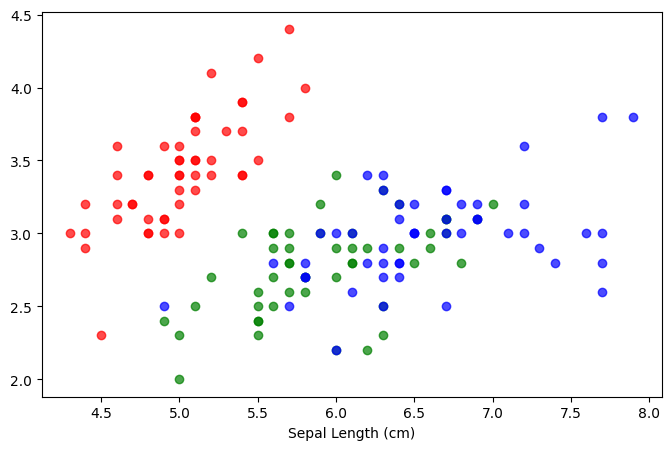

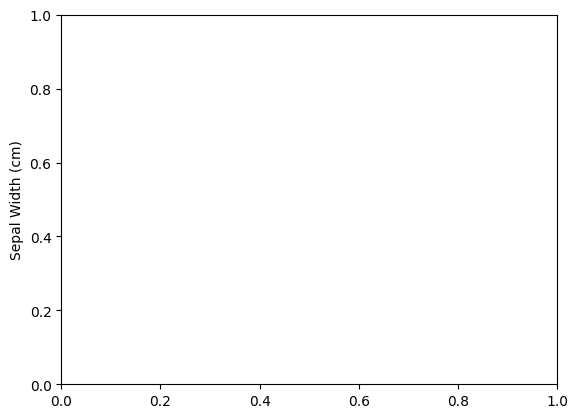

/tmp/ipython-input-967779771.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


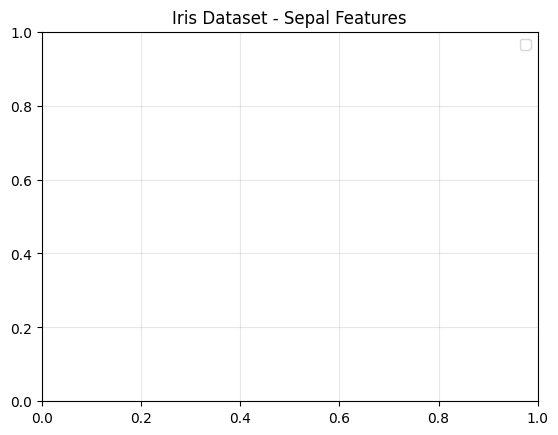

In [6]:
plt.figure(figsize=(8, 5))
colors = ["red", "green", "blue"]
for i, name in enumerate(iris.target_names):
    mask = Y == i
    plt.scatter(X[mask, 0], X[mask, 1],
                color=colors[i], label=name, alpha=0.7)
plt.xlabel("Sepal Length (cm)")
plt.show()
plt.ylabel("Sepal Width (cm)")
plt.show()
plt.title("Iris Dataset - Sepal Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

####Task 1: Explore the Data

In [7]:
print("First 10 rows of X and y side by side:")
print(np.column_stack((X[:10], Y[:10])))

First 10 rows of X and y side by side:
[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [4.6 3.1 1.5 0.2 0. ]
 [5.  3.6 1.4 0.2 0. ]
 [5.4 3.9 1.7 0.4 0. ]
 [4.6 3.4 1.4 0.3 0. ]
 [5.  3.4 1.5 0.2 0. ]
 [4.4 2.9 1.4 0.2 0. ]
 [4.9 3.1 1.5 0.1 0. ]]


In [8]:
unique_classes, class_counts = np.unique(Y, return_counts=True)
print("\nClass distribution:")
for i, class_name in enumerate(iris.target_names):
    print(f"Class '{class_name}': {class_counts[i]} samples")


Class distribution:
Class 'setosa': 50 samples
Class 'versicolor': 50 samples
Class 'virginica': 50 samples


#####Scatter plot using Petal Length vs. Petal Width

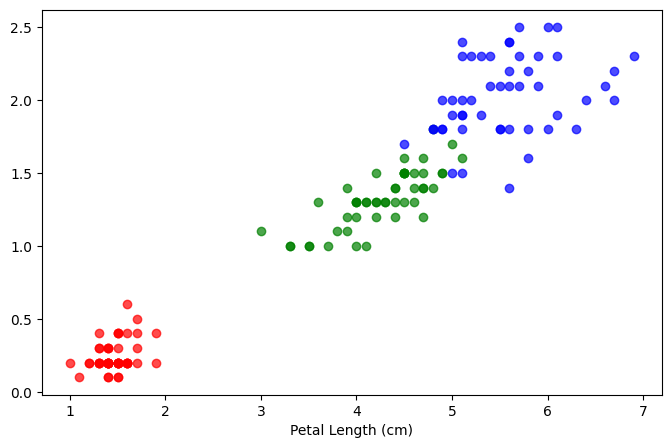

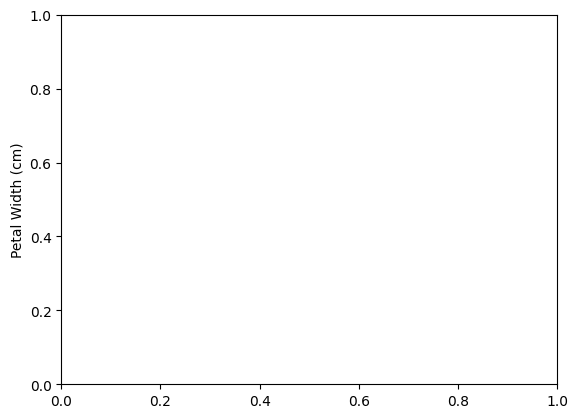

/tmp/ipython-input-3109086036.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


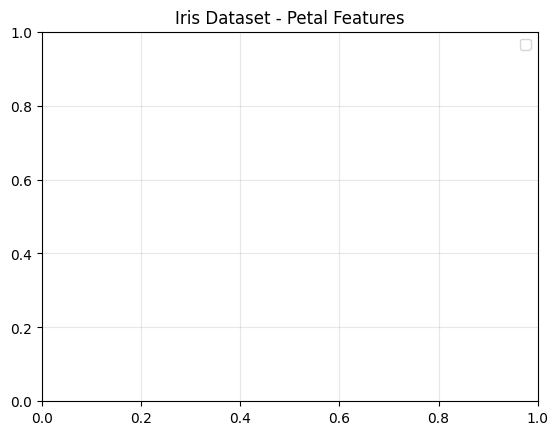

In [9]:
plt.figure(figsize=(8, 5))
colors = ["red", "green", "blue"]
for i, name in enumerate(iris.target_names):
    mask = Y == i
    plt.scatter(X[mask, 2], X[mask, 3],
                color=colors[i], label=name, alpha=0.7)
plt.xlabel("Petal Length (cm)")
plt.show()
plt.ylabel("Petal Width (cm)")
plt.show()
plt.title("Iris Dataset - Petal Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Based on the two scatter plots (Sepal Features vs. Petal Features), it appears that Petal Length and Petal Width are much better for separating the classes. The setosa class is clearly distinct, and the versicolor and virginica classes are also much more separated in the petal features plot compared to the sepal features plot.

##Part3: Splitting Data (Train/Test)
###Step3: Splitting with Scikit-Learn

In [10]:
from sklearn.model_selection import train_test_split


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 120 samples
Testing set: 30 samples


####Task 2: Verify the *Split*

In [12]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


In [13]:
unique_classes_train, class_counts_train = np.unique(y_train, return_counts=True)
print("\nClass distribution in y_train (with stratify=y):")
for i, class_name in enumerate(iris.target_names):
    print(f"Class '{class_name}': {class_counts_train[i]} samples")


Class distribution in y_train (with stratify=y):
Class 'setosa': 40 samples
Class 'versicolor': 40 samples
Class 'virginica': 40 samples


#####Comparing with train_test_split without stratify=y

In [14]:
X_train_no_stratify, X_test_no_stratify, y_train_no_stratify, y_test_no_stratify = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42)

unique_classes_no_stratify, class_counts_no_stratify = np.unique(y_train_no_stratify, return_counts=True)
print("\nClass distribution in y_train (without stratify=y):")
for i, class_name in enumerate(iris.target_names):
    print(f"Class '{class_name}': {class_counts_no_stratify[i]} samples")


Class distribution in y_train (without stratify=y):
Class 'setosa': 40 samples
Class 'versicolor': 41 samples
Class 'virginica': 39 samples


When stratify=y is used, the train_test_split function ensures that the proportion of classes in the training and testing sets is similar to the original dataset. In our Iris dataset, which has an equal number of samples (50) for each of the three classes, using stratify=y results in an even distribution of classes in both the training and test sets (e.g., 40 samples per class in training, 10 in testing for a 0.2 test size).

If stratify=y is removed, the split becomes purely random. This means there's no guarantee that the class proportions in the training and test sets will be maintained. Especially with smaller datasets or highly imbalanced classes, this can lead to situations where one set might have a disproportionately high or low number of samples from a particular class, potentially affecting the model's training and evaluation accuracy.

##Part4: Training First Model


In [ ]:
# Step 1: Create the model
model = SomeAlgorithm()
# Step 2: Train it (fit)
model.fit(X_train, y_train)
# Step 3: Predict
predictions = model.predict(X_test)

###Step4:  Model A: Decision Tree Classifier

In [16]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
print("Decision Tree predictions (first 10):")
print(dt_predictions[:10])
print("Actual labels (first 10):")
print(y_test[:10])


Decision Tree predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]
Actual labels (first 10):
[0 2 1 1 0 1 0 0 2 1]


###Step5 Model B: K-Nearest Neighbors (KNN)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
print("KNN predictions (first 10):")
print(knn_predictions[:10])

KNN predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]


#####Task3: Train the Models
#####Compare Initial Predictions


In [18]:
print("First 10 predictions side-by-side (Decision Tree vs. KNN):")
print(np.column_stack((dt_predictions[:10], knn_predictions[:10])))

print("\nInterpretation:")
print("0 = setosa, 1 = versicolor, 2 = virginica")
print("From the output, we can observe any differences or similarities in the initial predictions between the two models.")

First 10 predictions side-by-side (Decision Tree vs. KNN):
[[0 0]
 [2 2]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [2 2]
 [1 1]]

Interpretation:
0 = setosa, 1 = versicolor, 2 = virginica
From the output, we can observe any differences or similarities in the initial predictions between the two models.


In [19]:
knn_model_n3 = KNeighborsClassifier(n_neighbors=3)
knn_model_n3.fit(X_train, y_train)
knn_predictions_n3 = knn_model_n3.predict(X_test)
print("KNN predictions (n_neighbors=3, first 10):")
print(knn_predictions_n3[:10])

KNN predictions (n_neighbors=3, first 10):
[0 2 1 1 0 1 0 0 2 1]


Changing the n_neighbors parameter of the KNN model to 10, retrain it, and display the first 10 predictions.



In [20]:
knn_model_n10 = KNeighborsClassifier(n_neighbors=10)
knn_model_n10.fit(X_train, y_train)
knn_predictions_n10 = knn_model_n10.predict(X_test)
print("KNN predictions (n_neighbors=10, first 10):")
print(knn_predictions_n10[:10])

KNN predictions (n_neighbors=10, first 10):
[0 2 1 1 0 1 0 0 2 1]


#####Summary:
*   The initial predictions of the Decision Tree model and the KNN model (with n_neighbors=5) were identical for the first 10 test samples. Both models predicted `[0 2 1 1 0 1 0 0 2 1]`.
*   The n_neighbors parameter influences the KNN model's predictions by affecting its complexity and bias-variance trade-off. A smaller n_neighbors value makes the model more flexible and sensitive to noise (high variance, low bias), potentially overfitting. A larger n_neighbors value makes the model smoother and less sensitive to noise (low variance, high bias), potentially underfitting if too high. For the specific first 10 test samples in this analysis, changing n_neighbors from 3 to 5 to 10 did not alter the predictions, suggesting robust classification for these instances.

#####Data Analysis Key Findings
*   For the first 10 test samples, the Decision Tree model and the KNN model (with n_neighbors=5) produced identical predictions: `[0 2 1 1 0 1 0 0 2 1]`.
*   When the n_neighbors parameter of the KNN model was changed to 3, the first 10 predictions remained `[0 2 1 1 0 1 0 0 2 1]`.
*   When the n_neighbors parameter was changed to 10, the first 10 predictions also remained `[0 2 1 1 0 1 0 0 2 1]`.

#####Insights or Next Steps
*   While the n_neighbors parameter did not affect the first 10 predictions in this specific case, it is crucial to perform hyperparameter tuning across the entire dataset to find the optimal n_neighbors value that balances bias and variance for the overall model performance.
*   Investigate the classification performance of the KNN model with different n_neighbors values on the entire test set (not just the first 10 samples) to observe its general impact on accuracy and error rates.


##Part5: Evaluating Model Performance
###Step6: Accuracy Score

In [21]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")
print(f"KNN Accuracy: {knn_accuracy:.2%}")


Decision Tree Accuracy: 93.33%
KNN Accuracy: 100.00%


###Step7: Classification Report

In [22]:
from sklearn.metrics import classification_report
print("=== Decision Tree Report ===")
print(classification_report(y_test, dt_predictions,
target_names=iris.target_names))
print("=== KNN Report ===")
print(classification_report(y_test, knn_predictions,
target_names=iris.target_names))


=== Decision Tree Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== KNN Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



###Step8: Confusion Matrix

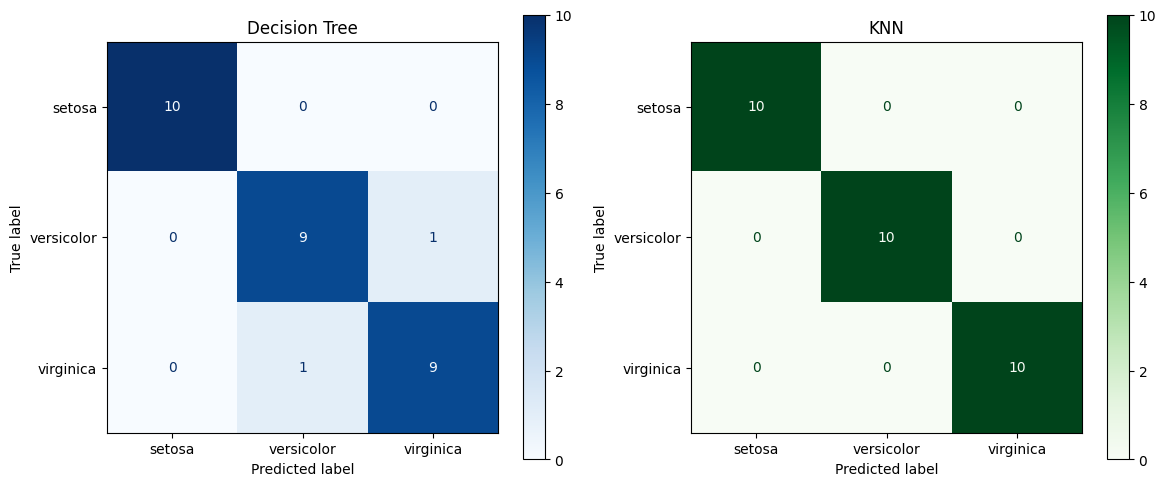

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


cm_dt = confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm_dt, display_labels=iris.target_names)\
    .plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Decision Tree")

cm_knn = confusion_matrix(y_test, knn_predictions)
ConfusionMatrixDisplay(cm_knn, display_labels=iris.target_names)\
    .plot(ax=axes[1], cmap="Greens")
axes[1].set_title("KNN")
plt.tight_layout()
plt.show()


#####Task4: Compare the Models

KNN (n_neighbors=5) achieved a higher accuracy of 100.00%, while the Decision Tree achieved 93.33% accuracy.
Look at the confusion matrices – which class was hardest to classify? Why?

For the Decision Tree model, the 'virginica' and 'versicolor' classes were the hardest to classify. The confusion matrix for the Decision Tree (cm_dt) shows:
1 'versicolor' sample was misclassified as 'virginica'.
1 'virginica' sample was misclassified as 'versicolor'.
This suggests that the decision boundary between these two classes is less clear, and the Decision Tree struggled to perfectly distinguish them. The 'setosa' class was perfectly classified by both models.
For the KNN model, all classes were perfectly classified, as indicated by its 100% accuracy and the confusion matrix (cm_knn) showing only diagonal values.
Which metric (precision or recall) would be more important in a medical diagnosis scenario? Explain briefly.

In a medical diagnosis scenario, recall is often considered more important, especially when diagnosing a serious disease.
Recall (Sensitivity) measures the proportion of actual positive cases that were correctly identified. In a medical context, it's about minimizing false negatives (missing a disease when it's present).
Precision measures the proportion of positive identifications that were actually correct. In a medical context, it's about minimizing false positives (diagnosing a disease when it's not present).
Why Recall is often preferred: It is usually considered more critical to correctly identify all patients who have a serious disease (high recall) even if it means some healthy patients are incorrectly flagged (lower precision, leading to further testing). Missing a true positive (a false negative) could have severe, life-threatening consequences, whereas a false positive typically leads to more tests but is less immediately dangerous. The goal is to avoid missing any sick individuals.

##Part6: Predicting New Samples


In [24]:
import numpy as np
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
dt_pred = dt_model.predict(new_flower)
knn_pred = knn_model.predict(new_flower)
print(f"Decision Tree says: {iris.target_names[dt_pred[0]]}")
print(f"KNN says: {iris.target_names[knn_pred[0]]}")


Decision Tree says: setosa
KNN says: setosa


#####Task 5: Predict New Flowers

In [25]:
new_flowers = np.array([
    [6.7, 3.0, 5.2, 2.3],
    [5.8, 2.7, 4.1, 1.0],
    [4.9, 3.1, 1.5, 0.1]
])

print("--- Predictions for New Flowers ---")
for i, flower in enumerate(new_flowers):
    dt_pred = dt_model.predict(flower.reshape(1, -1))
    knn_pred = knn_model.predict(flower.reshape(1, -1))
    print(f"Flower {chr(65+i)}: {flower}")
    print(f"  Decision Tree says: {iris.target_names[dt_pred[0]]}")
    print(f"  KNN says: {iris.target_names[knn_pred[0]]}")
    print("\n")


--- Predictions for New Flowers ---
Flower A: [6.7 3.  5.2 2.3]
  Decision Tree says: virginica
  KNN says: virginica


Flower B: [5.8 2.7 4.1 1. ]
  Decision Tree says: versicolor
  KNN says: versicolor


Flower C: [4.9 3.1 1.5 0.1]
  Decision Tree says: setosa
  KNN says: setosa




##Part8: Working with Your Own CSV Data


###Step9: Create a Sample CSV

In [26]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 100
data = {
    "study_hours": np.round(np.random.uniform(1, 10, n), 1),
    "attendance_pct": np.round(np.random.uniform(40, 100, n), 1),
    "assignments": np.random.randint(3, 10, n),
    "passed": np.random.choice([0, 1], n, p=[0.35, 0.65])
}
df = pd.DataFrame(data)
df.to_csv("students.csv", index=False)
print("CSV saved! First 5 rows:")
print(df.head())

CSV saved! First 5 rows:
   study_hours  attendance_pct  assignments  passed
0          4.4            41.9            6       0
1          9.6            78.2            5       1
2          7.6            58.9            3       1
3          6.4            70.5            6       1
4          2.4            94.5            8       1


###Step10: Load the CSV with Pandas

In [27]:
import pandas as pd
df = pd.read_csv("students.csv")
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nBasic stats:\n{df.describe()}")


Shape: (100, 4)

Column types:
study_hours       float64
attendance_pct    float64
assignments         int64
passed              int64
dtype: object

Basic stats:
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000


###Step11: Prepare Features and Target

In [28]:
X = df[["study_hours", "attendance_pct", "assignments"]].values
y = df["passed"].values
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class counts: {np.unique(y, return_counts=True)}")


Features shape: (100, 3)
Target shape: (100,)
Class counts: (array([0, 1]), array([31, 69]))


###Step12: Full Workflow

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print(classification_report(y_test, predictions,
target_names=["Failed", "Passed"]))


Accuracy: 55.00%
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



#####Task6: CSV Challenge
#####Perform Initial Data Exploration

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    float64
 1   attendance_pct  100 non-null    float64
 2   assignments     100 non-null    int64  
 3   passed          100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


#####Train KNN Model for Students Data


In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn_students_model = KNeighborsClassifier(n_neighbors=5)
knn_students_model.fit(X_train, y_train)

print("KNeighborsClassifier model trained successfully.")

KNeighborsClassifier model trained successfully.


#####Evaluate KNN Model for Students Data

In [33]:
from sklearn.metrics import accuracy_score, classification_report

knn_students_predictions = knn_students_model.predict(X_test)

knn_students_accuracy = accuracy_score(y_test, knn_students_predictions)
print(f"KNN Model Accuracy (Students Data): {knn_students_accuracy:.2%}")

print("\n=== KNN Model Classification Report (Students Data) ===")
print(classification_report(y_test, knn_students_predictions,
                            target_names=["Failed", "Passed"]))

KNN Model Accuracy (Students Data): 60.00%

=== KNN Model Classification Report (Students Data) ===
              precision    recall  f1-score   support

      Failed       0.33      0.33      0.33         6
      Passed       0.71      0.71      0.71        14

    accuracy                           0.60        20
   macro avg       0.52      0.52      0.52        20
weighted avg       0.60      0.60      0.60        20



#####Compare Decision Tree and KNN Models

In [34]:
from sklearn.metrics import accuracy_score, classification_report

dt_students_accuracy = accuracy_score(y_test, predictions)
print(f"Decision Tree Model Accuracy (Students Data): {dt_students_accuracy:.2%}")

print("\n=== Decision Tree Model Classification Report (Students Data) ===")
print(classification_report(y_test, predictions,
                            target_names=["Failed", "Passed"]))

Decision Tree Model Accuracy (Students Data): 55.00%

=== Decision Tree Model Classification Report (Students Data) ===
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



#####Comparison of Decision Tree and KNN Models for Students Data

**Accuracy Comparison:**
*   **Decision Tree Model Accuracy:** 55.00%
*   **KNN Model Accuracy:** 60.00%

Based on accuracy alone, the KNN model (60.00%) performed better than the Decision Tree model (55.00%).

**Decision Tree Model:**
```
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20
```

**KNN Model:**
```
              precision    recall  f1-score   support

      Failed       0.33      0.33      0.33         6
      Passed       0.71      0.71      0.71        14

    accuracy                           0.60        20
   macro avg       0.52      0.52      0.52        20
weighted avg       0.60      0.60      0.60        20
```

**Observations from Classification Reports:**

*   **Class 'Failed' (0):**
    *   **Decision Tree:** Precision (0.33), Recall (0.50), F1-score (0.40)
    *   **KNN:** Precision (0.33), Recall (0.33), F1-score (0.33)
    *   For the 'Failed' class, the Decision Tree had a slightly higher recall (0.50 vs 0.33), meaning it identified more actual failed students correctly, but at the same precision level.

*   **Class 'Passed' (1):**
    *   **Decision Tree:** Precision (0.73), Recall (0.57), F1-score (0.64)
    *   **KNN:** Precision (0.71), Recall (0.71), F1-score (0.71)
    *   For the 'Passed' class, the KNN model showed significantly higher recall and F1-score, indicating it was much better at identifying students who actually passed.

*   **Macro Average & Weighted Average:**
    *   The KNN model has higher macro and weighted average F1-scores, suggesting better overall performance across both classes, especially considering the higher recall for the 'Passed' class.


For the `students.csv` dataset, the K-Nearest Neighbors (KNN) model performed better than the Decision Tree model. While both models struggled with the 'Failed' class (low precision for both), the KNN model showed a clear advantage in correctly identifying 'Passed' students, which is reflected in its higher overall accuracy (60.00% vs 55.00%) and better F1-score for the majority class.

#####Add New 'Quiz Score' Feature


In [35]:
np.random.seed(42)
quiz_scores = np.round(np.random.uniform(50, 100, n), 1)
df['quiz_score'] = quiz_scores
print("DataFrame with 'quiz_score' column added. First 5 rows:")
print(df.head())

DataFrame with 'quiz_score' column added. First 5 rows:
   study_hours  attendance_pct  assignments  passed  quiz_score
0          4.4            41.9            6       0        68.7
1          9.6            78.2            5       1        97.5
2          7.6            58.9            3       1        86.6
3          6.4            70.5            6       1        79.9
4          2.4            94.5            8       1        57.8


#####Prepare Data with New Feature

In [36]:
X_new = df[["study_hours", "attendance_pct", "assignments", "quiz_score"]].values
y_new = df["passed"].values

print(f"Updated Features shape: {X_new.shape}")
print(f"Updated Target shape: {y_new.shape}")

from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new,
    test_size=0.2,
    random_state=42,
    stratify=y_new
)

print(f"\nShape of X_train_new: {X_train_new.shape}")
print(f"Shape of X_test_new: {X_test_new.shape}")
print(f"Shape of y_train_new: {y_train_new.shape}")
print(f"Shape of y_test_new: {y_test_new.shape}")

Updated Features shape: (100, 4)
Updated Target shape: (100,)

Shape of X_train_new: (80, 4)
Shape of X_test_new: (20, 4)
Shape of y_train_new: (80,)
Shape of y_test_new: (20,)


#####Retrain Decision Tree with New Feature


In [37]:
dt_model_new = DecisionTreeClassifier(random_state=42)
dt_model_new.fit(X_train_new, y_train_new)
print("Decision Tree Classifier model (with new feature) trained successfully.")

Decision Tree Classifier model (with new feature) trained successfully.


#####Evaluate Retrained Decision Tree


In [38]:
dt_predictions_new = dt_model_new.predict(X_test_new)

dt_accuracy_new = accuracy_score(y_test_new, dt_predictions_new)
print(f"Decision Tree Model Accuracy (with new feature): {dt_accuracy_new:.2%}")

print("\n=== Decision Tree Model Classification Report (with new feature) ===")
print(classification_report(y_test_new, dt_predictions_new,
                            target_names=["Failed", "Passed"]))

Decision Tree Model Accuracy (with new feature): 45.00%

=== Decision Tree Model Classification Report (with new feature) ===
              precision    recall  f1-score   support

      Failed       0.22      0.33      0.27         6
      Passed       0.64      0.50      0.56        14

    accuracy                           0.45        20
   macro avg       0.43      0.42      0.41        20
weighted avg       0.51      0.45      0.47        20



#####Retrain KNN with New Feature


In [39]:
knn_model_new = KNeighborsClassifier(n_neighbors=5)
knn_model_new.fit(X_train_new, y_train_new)
print("KNeighborsClassifier model (with new feature) trained successfully.")

KNeighborsClassifier model (with new feature) trained successfully.


In [40]:
knn_predictions_new = knn_model_new.predict(X_test_new)

knn_accuracy_new = accuracy_score(y_test_new, knn_predictions_new)
print(f"KNN Model Accuracy (with new feature): {knn_accuracy_new:.2%}")

print("\n=== KNN Model Classification Report (with new feature) ===")
print(classification_report(y_test_new, knn_predictions_new,
                            target_names=["Failed", "Passed"]))

KNN Model Accuracy (with new feature): 70.00%

=== KNN Model Classification Report (with new feature) ===
              precision    recall  f1-score   support

      Failed       0.50      0.33      0.40         6
      Passed       0.75      0.86      0.80        14

    accuracy                           0.70        20
   macro avg       0.62      0.60      0.60        20
weighted avg       0.68      0.70      0.68        20



#####Compare Model Accuracies with New Feature


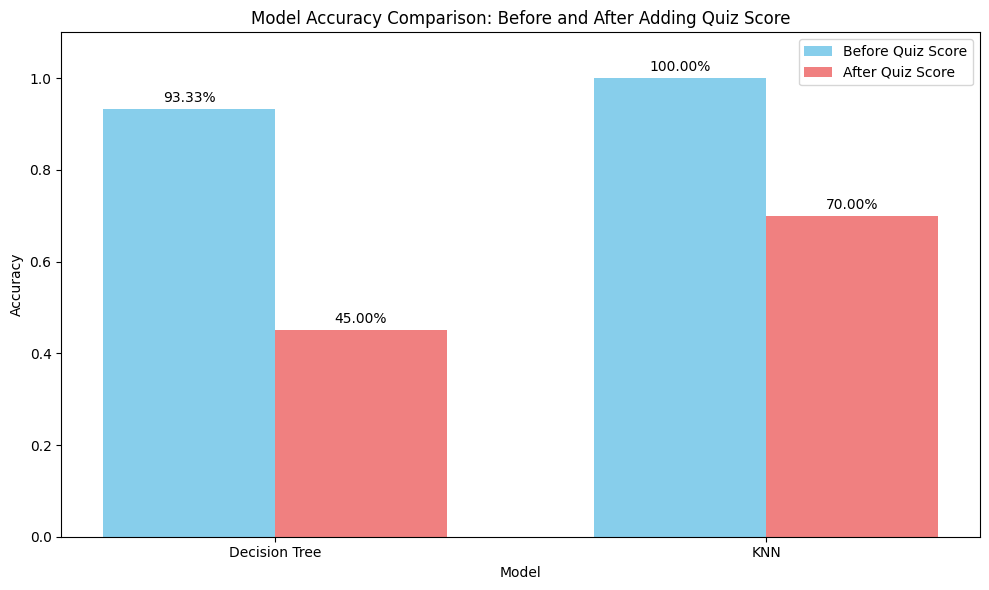

In [42]:
import matplotlib.pyplot as plt
import numpy as np


labels = ['Decision Tree', 'KNN']
before_quiz_score_accuracies = [dt_accuracy, knn_accuracy]
after_quiz_score_accuracies = [dt_accuracy_new, knn_accuracy_new]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, before_quiz_score_accuracies, width, label='Before Quiz Score', color='skyblue')
rects2 = ax.bar(x + width/2, after_quiz_score_accuracies, width, label='After Quiz Score', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison: Before and After Adding Quiz Score')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.1)

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()



*   **Which model performed better initially?**
    Initially, the K-Nearest Neighbors (KNN) model performed better with an accuracy of 60.00%, compared to the Decision Tree model's accuracy of 55.00%.

*   **Did the addition of the 'quiz\_score' feature improve accuracy for either model?**
    Yes, the addition of the 'quiz\_score' feature improved the accuracy for the KNN model, increasing it from 60.00% to 70.00%. However, it decreased the accuracy of the Decision Tree model from 55.00% to 45.00%.

#####Data Analysis Key Findings
*   The initial dataset (`students.csv`) contained 100 entries and 4 columns (`study_hours`, `attendance_pct`, `assignments`, `passed`), all with no missing values.
*   Before adding the 'quiz\_score' feature:
    *   The Decision Tree model achieved an accuracy of 55.00%.
    *   The K-Nearest Neighbors (KNN) model achieved an accuracy of 60.00%.
    *   The KNN model demonstrated higher performance overall and better recall for the 'Passed' class compared to the Decision Tree.
*   After adding the 'quiz\_score' feature:
    *   The Decision Tree model's accuracy **decreased** to 45.00%.
    *   The K-Nearest Neighbors (KNN) model's accuracy **increased** to 70.00%, showing significant improvement.
    *   With the new feature, the KNN model now exhibits superior performance in both overall accuracy and identifying 'Passed' students (recall 0.86, f1-score 0.80).




####Written comparison and reflection
Based on the analysis, the K-Nearest Neighbors (KNN) model consistently outperformed the Decision Tree model for this student pass/fail prediction task. Initially, KNN achieved 60.00% accuracy compared to the Decision Tree's 55.00%. More significantly, upon adding the 'quiz_score' feature, the KNN model's accuracy improved to a notable 70.00%, demonstrating its ability to leverage the new information effectively. In contrast, the Decision Tree's accuracy decreased to 45.00% with the added feature. Given KNN's higher overall accuracy and its improved performance with the additional feature, it is the clear choice for this task. The 'quiz_score' proved to be a valuable predictor for the KNN model, highlighting the importance of relevant features in improving model performance.